# Zadatak

Primjenom Linearne regresije kreirati model koji ce nam omoguciti predvidanje potrosnje energije radnog stroja koja je u datasetu pohranjena u stupcu `energy_kwh`.

Dataset koji treba koristiti `15_dataset_potrosnja_energije_strojeva.csv`.

Graficki prikazati rezultate kao i pocetne vrijednosti unutar dataseta.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.float_format', '{:,.2f}'.format)

In [2]:
df = pd.read_csv('data/15_dataset_potrosnja_energije_strojeva.csv')
df.head()

,machine_type,shift,maintenance_done_recently,runtime_hours,production_units,avg_load_pct,temperature_c,vibration_mm_s,idle_minutes,days_since_maintenance,energy_kwh
0,Compressor,Afternoon,No,17.27,1254,81.50,88.30,2.59,43.90,75,379.30
1,CNC,Afternoon,No,6.46,1008,84.80,67.90,0.99,11.10,119,293.30
2,CNC,Afternoon,No,12.35,653,75.90,75.40,1.84,29.30,72,238.80
3,CNC,Afternoon,Yes,14.45,1121,41.30,69.30,2.60,40.50,57,225.00
4,CNC,Afternoon,No,11.88,714,72.30,79.20,8.53,32.70,91,278.80


In [3]:
df.shape

(1500, 11)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   machine_type               1500 non-null   str    
 1   shift                      1500 non-null   str    
 2   maintenance_done_recently  1500 non-null   str    
 3   runtime_hours              1500 non-null   float64
 4   production_units           1500 non-null   int64  
 5   avg_load_pct               1500 non-null   float64
 6   temperature_c              1500 non-null   float64
 7   vibration_mm_s             1500 non-null   float64
 8   idle_minutes               1500 non-null   float64
 9   days_since_maintenance     1500 non-null   int64  
 10  energy_kwh                 1500 non-null   float64
dtypes: float64(6), int64(2), str(3)
memory usage: 129.0 KB


In [5]:
df.describe()

,runtime_hours,production_units,avg_load_pct,temperature_c,vibration_mm_s,idle_minutes,days_since_maintenance,energy_kwh
count,"1,500.00","1,500.00","1,500.00","1,500.00","1,500.00","1,500.00","1,500.00","1,500.00"
mean,12.28,894.84,70.12,65.75,2.58,45.78,59.99,278.96
std,6.62,269.47,18.25,16.88,1.99,19.55,34.50,62.41
min,1.00,293.00,25.60,28.70,0.03,0.00,1.00,110.40
25%,6.66,694.75,55.70,52.48,1.15,32.40,32.00,235.45
50%,12.46,873.00,68.70,63.75,2.04,45.30,60.00,274.15
75%,17.79,"1,071.00",84.30,77.12,3.40,58.90,90.00,321.73
max,23.98,"1,807.00",100.00,127.40,14.08,117.10,119.00,472.60


Text(0.5, 0, 'Potrosnja energije (kWh)')

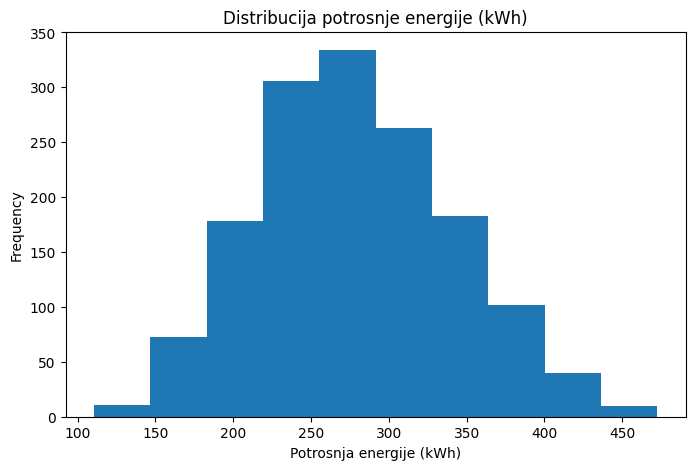

In [6]:
df['energy_kwh'].plot(
    kind='hist',
    figsize=(8, 5),
    title='Distribucija potrosnje energije (kWh)'
)

plt.xlabel('Potrosnja energije (kWh)')

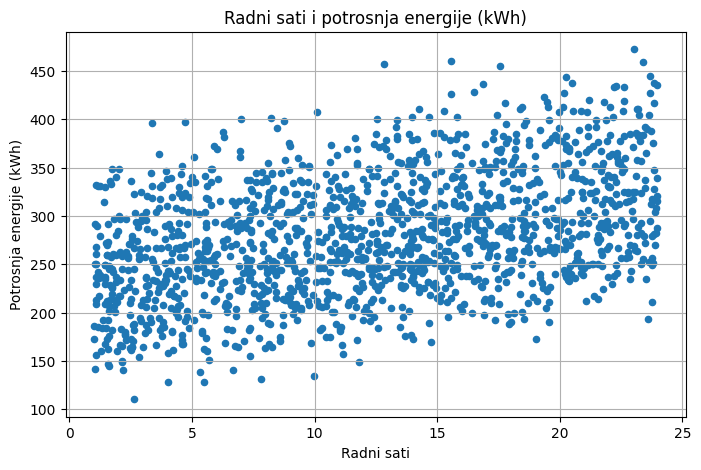

In [7]:
df.plot(
    kind='scatter',
    x='runtime_hours',
    y='energy_kwh',
    figsize=(8, 5),
    title='Radni sati i potrosnja energije (kWh)'
)

plt.xlabel('Radni sati')
plt.ylabel('Potrosnja energije (kWh)')
plt.grid(True)

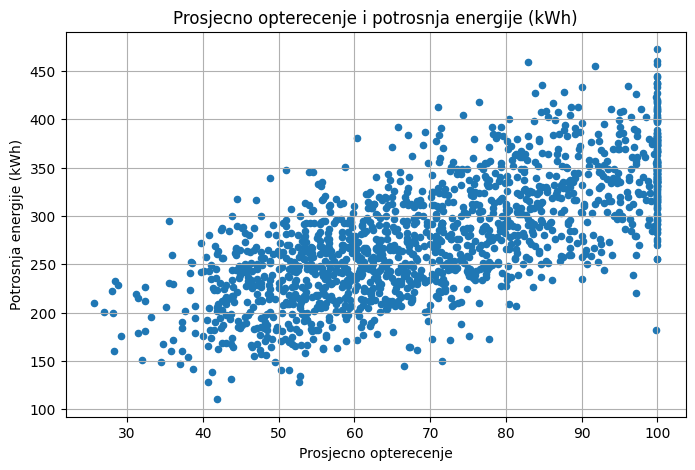

In [8]:
df.plot(
    kind='scatter',
    x='avg_load_pct',
    y='energy_kwh',
    figsize=(8, 5),
    title='Prosjecno opterecenje i potrosnja energije (kWh)'
)

plt.xlabel('Prosjecno opterecenje')
plt.ylabel('Potrosnja energije (kWh)')
plt.grid(True)

In [9]:
kolone = ['machine_type', 'shift', 'maintenance_done_recently', 'energy_kwh']

X = df.drop(columns=kolone)
y = df['energy_kwh']

# X_encoded = pd.get_dummies(X, columns=kolone)
# X_encoded.head()

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [11]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
y_pred_linear = linear_model.predict(X_test)

In [13]:
mea = mean_absolute_error(y_test, y_pred_linear)
mea

19.00654131675414

In [14]:
r2 = r2_score(y_test, y_pred_linear)
r2

0.856114234299798

In [15]:
tree_model = DecisionTreeRegressor(max_depth=6, random_state=42)
tree_model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [16]:
y_pred_tree = tree_model.predict(X_test)

In [17]:
mea = mean_absolute_error(y_test, y_pred_tree)
mea

27.830565524063246

In [18]:
r2 = r2_score(y_test, y_pred_tree)
r2

0.6673577908960389

In [19]:
forest_model = RandomForestRegressor(max_depth=8, random_state=42)
forest_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [20]:
y_pred_forest = forest_model.predict(X_test)

In [21]:
mea = mean_absolute_error(y_test, y_pred_forest)
mea

21.834833905418918

In [22]:
r2 = r2_score(y_test, y_pred_forest)
r2

0.8053713644049776

In [23]:
forest = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred_forest
})

forest.head()

,actual,predicted
0,319.90,322.60
1,237.50,221.44
2,189.30,236.67
3,369.40,370.17
4,283.70,281.57


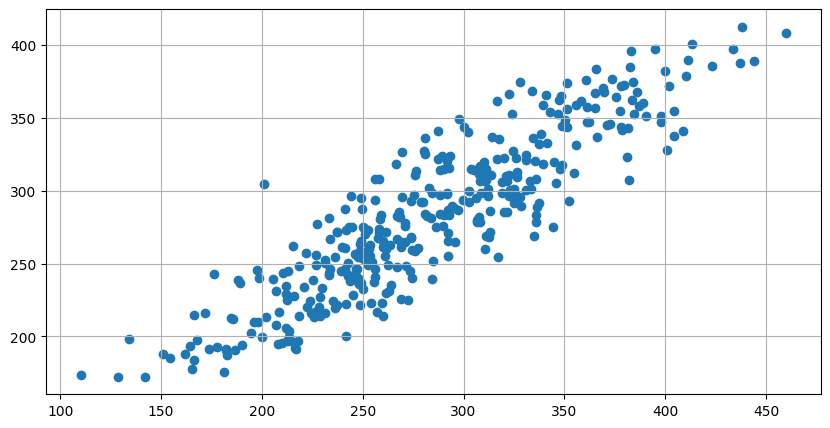

In [24]:
plt.figure(figsize=(10, 5))
plt.scatter(forest['actual'], forest['predicted'])
plt.grid(True)
plt.show()

In [25]:
df.describe()

,runtime_hours,production_units,avg_load_pct,temperature_c,vibration_mm_s,idle_minutes,days_since_maintenance,energy_kwh
count,"1,500.00","1,500.00","1,500.00","1,500.00","1,500.00","1,500.00","1,500.00","1,500.00"
mean,12.28,894.84,70.12,65.75,2.58,45.78,59.99,278.96
std,6.62,269.47,18.25,16.88,1.99,19.55,34.50,62.41
min,1.00,293.00,25.60,28.70,0.03,0.00,1.00,110.40
25%,6.66,694.75,55.70,52.48,1.15,32.40,32.00,235.45
50%,12.46,873.00,68.70,63.75,2.04,45.30,60.00,274.15
75%,17.79,"1,071.00",84.30,77.12,3.40,58.90,90.00,321.73
max,23.98,"1,807.00",100.00,127.40,14.08,117.10,119.00,472.60


In [28]:
new_machine = pd.DataFrame({
    'runtime_hours': [16.50], 
    'production_units': [1980],
    'avg_load_pct': [30.00],
    'temperature_c': [91.30],
    'vibration_mm_s': [1.59],
    'idle_minutes': [45.90],
    'days_since_maintenance': [15]
})

new_machine

,runtime_hours,production_units,avg_load_pct,temperature_c,vibration_mm_s,idle_minutes,days_since_maintenance
0,16.50,1980,30.00,91.30,1.59,45.90,15


In [30]:
predicted_energy = forest_model.predict(new_machine)[0]
predicted_energy

np.float64(300.174816781258)